In [1]:
from pathlib import Path
from labctl.experiments import PolarisationFilterSweepExperiment

dest_folder = Path(r"/Volumes/research/FSE_CCE/data/martijn/250106/")
# dest_folder = Path(r"/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Contributions/CH4_H2/experiment")
dest_folder.mkdir(exist_ok=True)

input('Please be careful with overriding existing files. Press enter to continue.')

''

# Polarisation filter calibration
**Users**: Martijn, Omid <br/>
*Used when the spectrometer optics stack contains a rotation stage for a polarisation filter. This script will make an angle sweep to determine the position corresponding to vertical polarisation.*

In [2]:
import numpy as np
degrees = np.arange(0, 360, 20)

experiment = PolarisationFilterSweepExperiment(
        short_explanation = "",
        author = "Martijn",
        n_iter = 1,
        n_frames = [10 for _ in degrees],
        t_exposure = 0.5,
        camera_delay_optimum=454e-9,
        # camera_delay_optimum=410e-9,
        dest_folder = dest_folder,
        file_name = "07_calibration_360",
        alpha = degrees,
    )

experiment.save_all()

Pulses per frame: 16
Total wait: 6.8min
NB: Put the PDG in burst mode
Kinetic acquisition settings:
	Exposure time:		0.517s
	Accumulation count:	1
	Frame count:		360


In [3]:
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt


f_pickle = "/Volumes/research/FSE_CCE/data/Omid/2025 07 30 - setup2/07_calibr_360_0.1s_idx.pkl"  # Replace with path of the ..._idx.pkl file
f_data = "/Volumes/research/FSE_CCE/data/Omid/2025 07 30 - setup2/02_532nnm_O2 gas_5slm_600mbar_1700gr_50um_pol calibr_0.1s.sif"  # Replace with path of the .sif file

# Load pickle file
info = pickle.load(open(f_pickle, "rb"))
print(info.keys())
print(info["configs"])

# Load sif file
print("Loading image data...")
data, _ = sif_parser.np_open(f_data)


def get_data(data, info, config):
    # Get the keys for the signal and background indices
    sig_key = f"{config}_sig"
    bg_key = f"{config}_bg"

    if not sig_key in info:
        return None, None

    # Get the indices for the signal and background
    sig_ind = info[sig_key]
    bg_ind = info[bg_key]

    # Get the data for the signal and background
    sig_data = data[sig_ind[0], :, :]
    bg_data = data[bg_ind[0], :, :]

    sig_data_avg = np.squeeze(np.median(sig_data, axis=0))
    bg_data_avg = np.squeeze(np.median(bg_data, axis=0))

    return sig_data_avg, bg_data_avg, sig_data_avg - bg_data_avg

configs = np.arange(0, len(info['configs']))
degs = np.array([int(i.split('_')[1]) for i in info['configs']])
sigs = np.zeros((1024, configs.size))

for i in configs:
    _, _, sigi = get_data(data, info, i)
    sigs[:, i] = sigi

dict_keys(['x', 'indices', '0_sig', '0_bg', '1_sig', '1_bg', '2_sig', '2_bg', '3_sig', '3_bg', '4_sig', '4_bg', '5_sig', '5_bg', '6_sig', '6_bg', '7_sig', '7_bg', '8_sig', '8_bg', '9_sig', '9_bg', '10_sig', '10_bg', '11_sig', '11_bg', '12_sig', '12_bg', '13_sig', '13_bg', '14_sig', '14_bg', '15_sig', '15_bg', '16_sig', '16_bg', '17_sig', '17_bg', '18_sig', '18_bg', '19_sig', '19_bg', '20_sig', '20_bg', '21_sig', '21_bg', '22_sig', '22_bg', '23_sig', '23_bg', '24_sig', '24_bg', '25_sig', '25_bg', '26_sig', '26_bg', '27_sig', '27_bg', '28_sig', '28_bg', '29_sig', '29_bg', '30_sig', '30_bg', '31_sig', '31_bg', '32_sig', '32_bg', '33_sig', '33_bg', '34_sig', '34_bg', '35_sig', '35_bg', '36_sig', '36_bg', '37_sig', '37_bg', '38_sig', '38_bg', '39_sig', '39_bg', '40_sig', '40_bg', '41_sig', '41_bg', '42_sig', '42_bg', '43_sig', '43_bg', '44_sig', '44_bg', '45_sig', '45_bg', '46_sig', '46_bg', '47_sig', '47_bg', '48_sig', '48_bg', '49_sig', '49_bg', '50_sig', '50_bg', '51_sig', '51_bg', '52_s

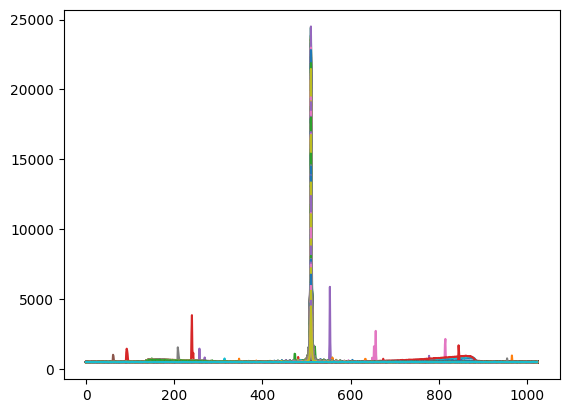

In [4]:
plt.plot(np.squeeze(data).T)
plt.show()

<Figure size 708x500 with 0 Axes>

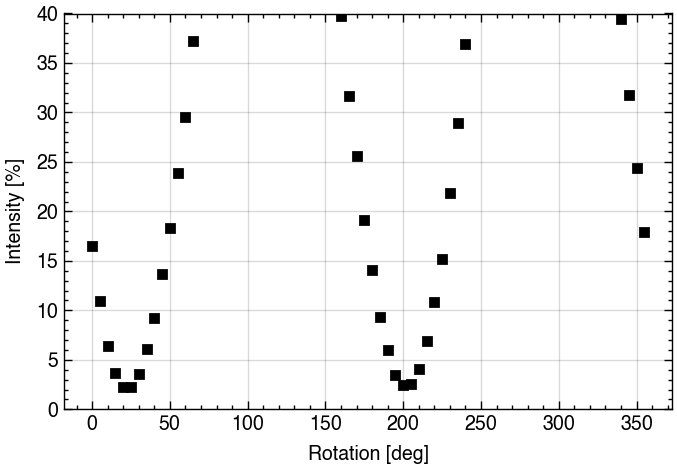

In [14]:
plt.figure()

# Select a range of interest for the signal
peak_sig = np.max(sigs[450:550, :], axis=0)
peak_sig /= np.max(peak_sig) # Normalize the peak signal

plt.figure()
plt.plot(degs, peak_sig*100, 'ks')
plt.xlabel("Rotation [deg]")
plt.ylabel("Intensity [%]")
plt.ylim(0, 40)
plt.show()

113.33224239101564


/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_11779/49043792.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fit_func, degs[idx_fit], peak_sig[idx_fit], p0=[0, 1, 0])


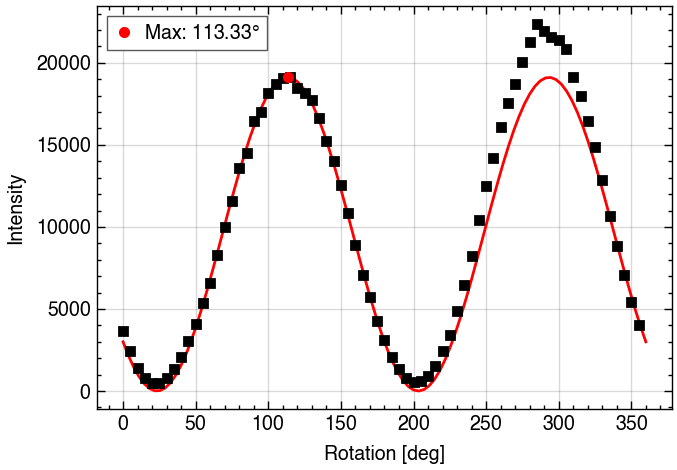

In [6]:
import wedme.apply.dev

# Fit (degs, vib_sig) with  y = A + B*sin(x*pi/180-C)
from scipy.optimize import curve_fit

def fit_func(x, A, B, C):
    return  B*np.cos(x*np.pi/180-C)**2

# Select a range of interest for the fit
# Usually, the signal doesn't look like a perfect sine. This can be because the filter has a slight tilt, such that the focal point might shift a bit.
idx_fit = (degs > 30) & (degs < 200)
popt, pcov = curve_fit(fit_func, degs[idx_fit], peak_sig[idx_fit], p0=[0, 1, 0])

x = np.linspace(0, 360, 100)
y = fit_func(x, *popt)

B_max = popt[1]
C_max = popt[2] % np.pi

ang_max = C_max*180/np.pi
print(ang_max)

plt.plot(x, y, 'r-')
plt.plot(degs, peak_sig, 'ks')
plt.plot(ang_max, B_max, 'ro', label=f'Max: {ang_max:.2f}$\degree$')
plt.xlabel("Rotation [deg]")
plt.ylabel("Intensity")
plt.legend()
plt.show()